# Experiment 9: Perceptron vs Multilayer Perceptron (A/B Experiment) with Hyperparameter Tuning

In [1]:
from IPython.display import display, Markdown

display(Markdown("""
# Experiment 9: Perceptron vs Multilayer Perceptron (A/B Experiment)

Prepared as a self-contained submission notebook using the Kaggle English Handwritten Characters dataset.
"""))


# Experiment 9: Perceptron vs Multilayer Perceptron (A/B Experiment)

Prepared as a self-contained submission notebook using the Kaggle English Handwritten Characters dataset.


## Aim

In [2]:
display(Markdown("""**Aim:** Implement a single-layer Perceptron Learning Algorithm (PLA) from scratch and a tuned Multilayer Perceptron (MLP), compare their performance on the English Handwritten Characters dataset (62 classes: 0-9, A-Z, a-z), and justify the MLP's chosen hyperparameters (activation, optimizer, learning rate, hidden layers, batch size) through systematic tuning."""))

**Aim:** Implement a single-layer Perceptron Learning Algorithm (PLA) from scratch and a tuned Multilayer Perceptron (MLP), compare their performance on the English Handwritten Characters dataset (62 classes: 0-9, A-Z, a-z), and justify the MLP's chosen hyperparameters (activation, optimizer, learning rate, hidden layers, batch size) through systematic tuning.

## Objective

In [3]:
display(Markdown("""
**Objectives**
- Preprocess the 3,410 handwritten character images (resize, grayscale, flatten, normalize).
- Implement Model A: a one-vs-rest ensemble of single-layer Perceptrons (step activation, classic PLA weight update rule), built from scratch with NumPy.
- Implement Model B: a Multilayer Perceptron with hidden layers, backpropagation, and a systematically tuned activation function, optimizer, learning rate, and batch size.
- Evaluate both models with Accuracy, Precision, Recall, F1-score, confusion matrix, ROC curves (micro/macro), and training convergence curves.
- Compare PLA vs. MLP, and answer the observation questions on why MLP outperforms PLA, which hyperparameters mattered most, and whether MLP overfit.
"""))


**Objectives**
- Preprocess the 3,410 handwritten character images (resize, grayscale, flatten, normalize).
- Implement Model A: a one-vs-rest ensemble of single-layer Perceptrons (step activation, classic PLA weight update rule), built from scratch with NumPy.
- Implement Model B: a Multilayer Perceptron with hidden layers, backpropagation, and a systematically tuned activation function, optimizer, learning rate, and batch size.
- Evaluate both models with Accuracy, Precision, Recall, F1-score, confusion matrix, ROC curves (micro/macro), and training convergence curves.
- Compare PLA vs. MLP, and answer the observation questions on why MLP outperforms PLA, which hyperparameters mattered most, and whether MLP overfit.


## Brief Theory

In [4]:
display(Markdown("""
**Brief Theory**
- **PLA (Perceptron Learning Algorithm)** uses a step activation function and the update rule $w_{t+1} = w_t + \\eta(y-\\hat y)x$, adjusting weights only on misclassified samples. It converges only for linearly separable data and has no hidden layers, so it can only learn a linear decision boundary.
- Since PLA is inherently a binary classifier, this experiment extends it to the 62-class problem via a **one-vs-rest ensemble of 62 independent Perceptrons**, one per character class, each trained with the same step-activation update rule; the class whose Perceptron gives the highest raw (pre-step) score is predicted.
- **MLP (Multilayer Perceptron)** stacks Input $\\to$ Hidden Layer(s) $\\to$ Output, using nonlinear activations (ReLU, Sigmoid, Tanh) and trained via backpropagation with a cross-entropy loss and a gradient-based optimizer (SGD, Adam). Hidden layers let it learn non-linear decision boundaries that a single-layer Perceptron cannot represent.
- Hyperparameter tuning (hidden layer sizes, activation, optimizer, learning rate, batch size) directly controls MLP's capacity and convergence speed/stability, which is why it is done systematically rather than using default values.
"""))


**Brief Theory**
- **PLA (Perceptron Learning Algorithm)** uses a step activation function and the update rule $w_{t+1} = w_t + \eta(y-\hat y)x$, adjusting weights only on misclassified samples. It converges only for linearly separable data and has no hidden layers, so it can only learn a linear decision boundary.
- Since PLA is inherently a binary classifier, this experiment extends it to the 62-class problem via a **one-vs-rest ensemble of 62 independent Perceptrons**, one per character class, each trained with the same step-activation update rule; the class whose Perceptron gives the highest raw (pre-step) score is predicted.
- **MLP (Multilayer Perceptron)** stacks Input $\to$ Hidden Layer(s) $\to$ Output, using nonlinear activations (ReLU, Sigmoid, Tanh) and trained via backpropagation with a cross-entropy loss and a gradient-based optimizer (SGD, Adam). Hidden layers let it learn non-linear decision boundaries that a single-layer Perceptron cannot represent.
- Hyperparameter tuning (hidden layer sizes, activation, optimizer, learning rate, batch size) directly controls MLP's capacity and convergence speed/stability, which is why it is done systematically rather than using default values.


## Import Libraries

In [5]:
import os
import re
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from IPython.display import display, Markdown
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import label_binarize
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc,
)

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
pd.set_option("display.max_colwidth", 200)
pd.set_option("display.precision", 4)
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## Configuration and Dataset Loading

In [6]:
DATASET_NAME = "English Handwritten Characters (Kaggle)"
DATA_DIR = "data"
IMAGE_SIZE = 32
OUTPUT_DIRECTORY = "experiment9_output"
PLOTS_DIRECTORY = os.path.join(OUTPUT_DIRECTORY, "plots")
os.makedirs(PLOTS_DIRECTORY, exist_ok=True)


def save_current_plot(filename: str):
    plt.tight_layout()
    plt.savefig(os.path.join(PLOTS_DIRECTORY, filename), bbox_inches="tight", dpi=150)
    plt.show()


from sklearn.preprocessing import LabelEncoder

labels_df = pd.read_csv(os.path.join(DATA_DIR, "english.csv"))
label_encoder = LabelEncoder()
labels_df["label_id"] = label_encoder.fit_transform(labels_df["label"])
class_names = label_encoder.classes_.tolist()
print(f"Dataset: {DATASET_NAME}")
print(f"Total images: {len(labels_df)}, Classes: {len(class_names)}")
print(f"Classes: {class_names}")
display(labels_df.head())
display(labels_df["label"].value_counts().sort_index().rename("count").to_frame().T)

Dataset: English Handwritten Characters (Kaggle)
Total images: 3410, Classes: 62
Classes: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']


,image,label,label_id
0,Img/img001-001.png,0,0
1,Img/img001-002.png,0,0
2,Img/img001-003.png,0,0
3,Img/img001-004.png,0,0
4,Img/img001-005.png,0,0


label,0,1,2,3,4,5,6,7,8,9,...,q,r,s,t,u,v,w,x,y,z
count,55,55,55,55,55,55,55,55,55,55,...,55,55,55,55,55,55,55,55,55,55


## Preprocessing: Resize, Grayscale, Flatten, Normalize

Preprocessed 3410 images to 32x32 grayscale (1024 features) in 7.55s
Pixel value range: [0.000, 1.000]


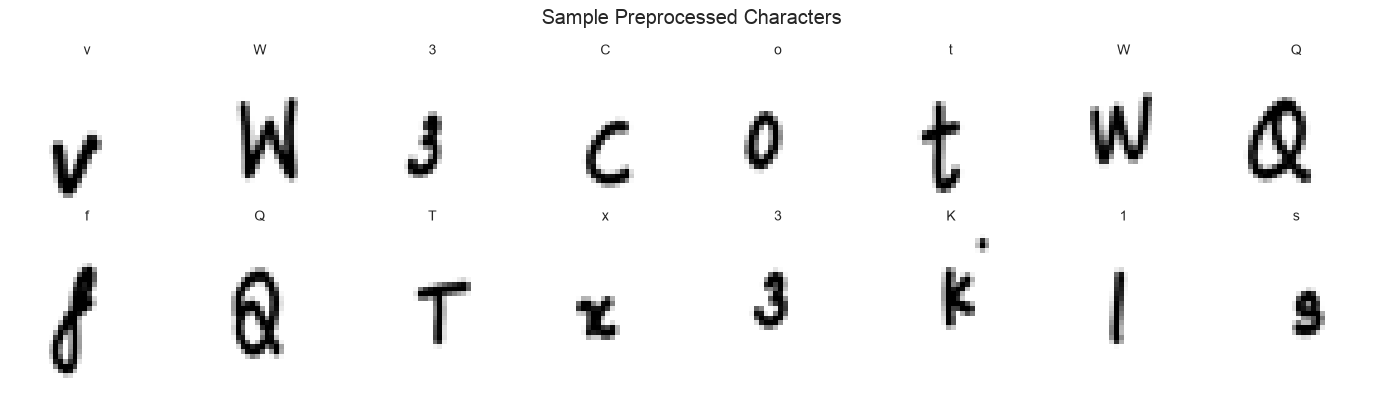

Train shape: (2728, 1024), Test shape: (682, 1024)


In [7]:
def load_and_preprocess(image_path):
    image = Image.open(os.path.join(DATA_DIR, image_path)).convert("L").resize((IMAGE_SIZE, IMAGE_SIZE))
    return np.asarray(image, dtype=np.float32).flatten() / 255.0


start_time = time.perf_counter()
X_all = np.stack([load_and_preprocess(p) for p in labels_df["image"]])
y_all = labels_df["label_id"].to_numpy()
preprocess_time = time.perf_counter() - start_time

print(f"Preprocessed {X_all.shape[0]} images to {IMAGE_SIZE}x{IMAGE_SIZE} grayscale ({X_all.shape[1]} features) in {preprocess_time:.2f}s")
print(f"Pixel value range: [{X_all.min():.3f}, {X_all.max():.3f}]")

fig, axes = plt.subplots(2, 8, figsize=(14, 4))
sample_idx = np.random.RandomState(RANDOM_STATE).choice(len(X_all), size=16, replace=False)
for ax, idx in zip(axes.flat, sample_idx):
    ax.imshow(X_all[idx].reshape(IMAGE_SIZE, IMAGE_SIZE), cmap="gray")
    ax.set_title(class_names[y_all[idx]], fontsize=10)
    ax.axis("off")
plt.suptitle("Sample Preprocessed Characters")
save_current_plot("sample_preprocessed_characters.png")

X_train, X_test, y_train, y_test = train_test_split(X_all, y_all, test_size=0.2, random_state=RANDOM_STATE, stratify=y_all)
print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")
n_classes = len(class_names)

## Model A: Perceptron Learning Algorithm (from scratch)

PLA training time: 7.39s (50 epochs)


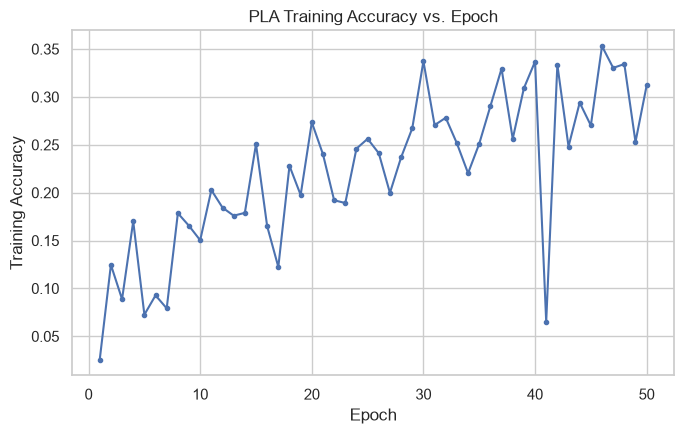

In [8]:
class OneVsRestPerceptron:
    """One-vs-rest ensemble of single-layer Perceptrons using the classic PLA update rule
    w_{t+1} = w_t + eta * (y - y_hat) * x with a step activation, implemented from scratch."""

    def __init__(self, n_classes, n_features, learning_rate=0.01, n_epochs=50, random_state=42):
        self.n_classes = n_classes
        self.learning_rate = learning_rate
        self.n_epochs = n_epochs
        rng = np.random.RandomState(random_state)
        self.weights = rng.normal(0, 0.01, size=(n_classes, n_features))
        self.bias = np.zeros(n_classes)
        self.epoch_train_accuracy = []

    @staticmethod
    def step(z):
        return np.where(z >= 0, 1, -1)

    def fit(self, X, y):
        n_samples = X.shape[0]
        y_one_vs_rest = -np.ones((n_samples, self.n_classes))
        y_one_vs_rest[np.arange(n_samples), y] = 1

        for epoch in range(self.n_epochs):
            order = np.random.permutation(n_samples)
            for idx in order:
                x_i = X[idx]
                z = self.weights @ x_i + self.bias
                y_hat = self.step(z)
                error = y_one_vs_rest[idx] - y_hat
                self.weights += self.learning_rate * np.outer(error, x_i)
                self.bias += self.learning_rate * error
            preds = self.predict(X)
            self.epoch_train_accuracy.append(accuracy_score(y, preds))
        return self

    def decision_function(self, X):
        return X @ self.weights.T + self.bias

    def predict(self, X):
        return np.argmax(self.decision_function(X), axis=1)


pla_start = time.perf_counter()
pla_model = OneVsRestPerceptron(n_classes=n_classes, n_features=X_train.shape[1], learning_rate=0.01, n_epochs=50, random_state=RANDOM_STATE)
pla_model.fit(X_train, y_train)
pla_train_time = time.perf_counter() - pla_start
print(f"PLA training time: {pla_train_time:.2f}s ({pla_model.n_epochs} epochs)")

plt.figure(figsize=(7, 4.5))
plt.plot(range(1, pla_model.n_epochs + 1), pla_model.epoch_train_accuracy, marker="o", markersize=3)
plt.xlabel("Epoch"); plt.ylabel("Training Accuracy")
plt.title("PLA Training Accuracy vs. Epoch")
save_current_plot("pla_training_curve.png")

## Model A: PLA Evaluation

In [9]:
pla_train_pred = pla_model.predict(X_train)
pla_test_pred = pla_model.predict(X_test)
pla_test_scores = pla_model.decision_function(X_test)

pla_metrics = {
    "Train Accuracy": accuracy_score(y_train, pla_train_pred),
    "Test Accuracy": accuracy_score(y_test, pla_test_pred),
    "Precision (macro)": precision_score(y_test, pla_test_pred, average="macro", zero_division=0),
    "Recall (macro)": recall_score(y_test, pla_test_pred, average="macro", zero_division=0),
    "F1 (macro)": f1_score(y_test, pla_test_pred, average="macro", zero_division=0),
}
display(pd.DataFrame([{"Model": "PLA (one-vs-rest)", **pla_metrics}]).round(4))

,Model,Train Accuracy,Test Accuracy,Precision (macro),Recall (macro),F1 (macro)
0,PLA (one-vs-rest),0.312,0.1804,0.3169,0.1804,0.1537


## Model B: MLP Hyperparameter Tuning

In [10]:
mlp_search_space = [
    {"hidden_layer_sizes": (128,), "activation": "relu", "solver": "adam", "learning_rate_init": 0.001, "batch_size": 64},
    {"hidden_layer_sizes": (128,), "activation": "tanh", "solver": "adam", "learning_rate_init": 0.001, "batch_size": 64},
    {"hidden_layer_sizes": (128, 64), "activation": "relu", "solver": "adam", "learning_rate_init": 0.001, "batch_size": 64},
    {"hidden_layer_sizes": (128, 64), "activation": "relu", "solver": "adam", "learning_rate_init": 0.01, "batch_size": 64},
    {"hidden_layer_sizes": (128, 64), "activation": "relu", "solver": "sgd", "learning_rate_init": 0.01, "batch_size": 64},
    {"hidden_layer_sizes": (128, 64), "activation": "relu", "solver": "adam", "learning_rate_init": 0.001, "batch_size": 128},
    {"hidden_layer_sizes": (256, 128), "activation": "relu", "solver": "adam", "learning_rate_init": 0.001, "batch_size": 64},
    {"hidden_layer_sizes": (128, 64, 32), "activation": "relu", "solver": "adam", "learning_rate_init": 0.001, "batch_size": 64},
]

X_tr_sub, X_val, y_tr_sub, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=RANDOM_STATE, stratify=y_train)

tuning_rows = []
for params in mlp_search_space:
    mlp = MLPClassifier(max_iter=300, random_state=RANDOM_STATE, early_stopping=False,
                         n_iter_no_change=30, tol=1e-5, alpha=1e-4, **params)
    start = time.perf_counter()
    mlp.fit(X_tr_sub, y_tr_sub)
    fit_time = time.perf_counter() - start
    val_acc = accuracy_score(y_val, mlp.predict(X_val))
    tuning_rows.append({**params, "Val Accuracy": round(val_acc, 4), "Train Time (s)": round(fit_time, 2), "Iterations": mlp.n_iter_})

tuning_table = pd.DataFrame(tuning_rows).sort_values("Val Accuracy", ascending=False).reset_index(drop=True)
display(tuning_table)

best_params = {k: tuning_table.iloc[0][k] for k in ["hidden_layer_sizes", "activation", "solver", "learning_rate_init", "batch_size"]}
print(f"Selected MLP hyperparameters: {best_params}")

,hidden_layer_sizes,activation,solver,learning_rate_init,batch_size,Val Accuracy,Train Time (s),Iterations
0,"(256, 128)",relu,adam,0.001,64,0.4469,8.17,300
1,"(128,)",tanh,adam,0.001,64,0.3059,4.03,300
2,"(128, 64)",relu,sgd,0.010,64,0.3059,2.65,284
3,"(128, 64)",relu,adam,0.001,64,0.2894,4.51,300
4,"(128, 64)",relu,adam,0.001,128,0.1300,2.70,300
5,"(128, 64)",relu,adam,0.010,64,0.0165,0.83,56
6,"(128,)",relu,adam,0.001,64,0.0147,2.04,148
7,"(128, 64, 32)",relu,adam,0.001,64,0.0147,2.86,181


Selected MLP hyperparameters: {'hidden_layer_sizes': (256, 128), 'activation': 'relu', 'solver': 'adam', 'learning_rate_init': np.float64(0.001), 'batch_size': np.int64(64)}


## Model B: Final MLP Training

MLP training time: 16.74s (500 iterations)


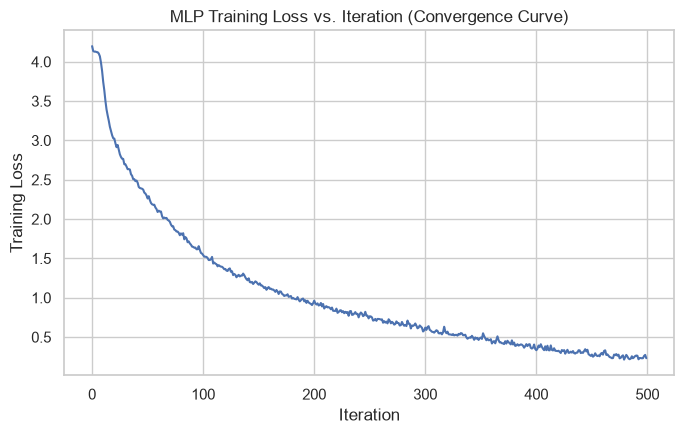

,Model,Train Accuracy,Test Accuracy,Precision (macro),Recall (macro),F1 (macro)
0,"MLP (256, 128)",0.9652,0.4355,0.4598,0.4355,0.4355


In [11]:
mlp_final = MLPClassifier(max_iter=500, random_state=RANDOM_STATE, early_stopping=False,
                           n_iter_no_change=30, tol=1e-5, alpha=1e-4, **best_params)
mlp_start = time.perf_counter()
mlp_final.fit(X_train, y_train)
mlp_train_time = time.perf_counter() - mlp_start
print(f"MLP training time: {mlp_train_time:.2f}s ({mlp_final.n_iter_} iterations)")

plt.figure(figsize=(7, 4.5))
plt.plot(mlp_final.loss_curve_)
plt.xlabel("Iteration"); plt.ylabel("Training Loss")
plt.title("MLP Training Loss vs. Iteration (Convergence Curve)")
save_current_plot("mlp_training_curve.png")

mlp_train_pred = mlp_final.predict(X_train)
mlp_test_pred = mlp_final.predict(X_test)
mlp_test_scores = mlp_final.predict_proba(X_test)

mlp_metrics = {
    "Train Accuracy": accuracy_score(y_train, mlp_train_pred),
    "Test Accuracy": accuracy_score(y_test, mlp_test_pred),
    "Precision (macro)": precision_score(y_test, mlp_test_pred, average="macro", zero_division=0),
    "Recall (macro)": recall_score(y_test, mlp_test_pred, average="macro", zero_division=0),
    "F1 (macro)": f1_score(y_test, mlp_test_pred, average="macro", zero_division=0),
}
display(pd.DataFrame([{"Model": f"MLP {best_params['hidden_layer_sizes']}", **mlp_metrics}]).round(4))

## Confusion Matrices

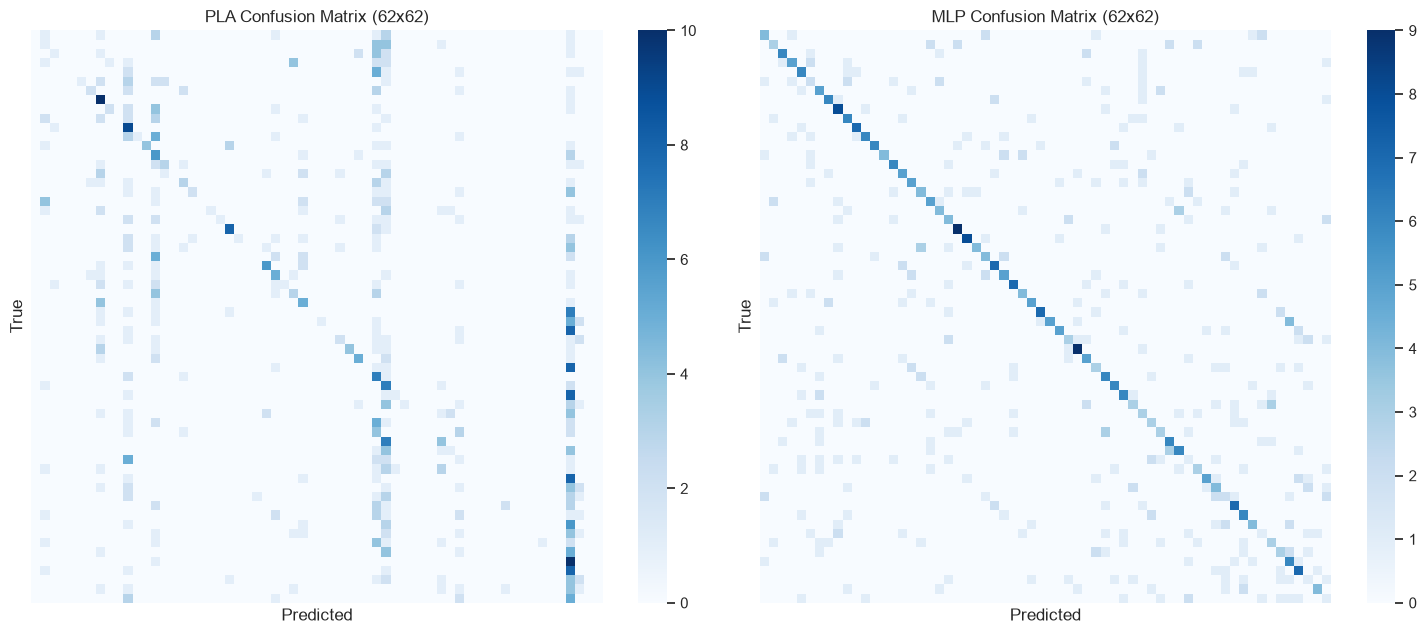

PLA correct diagonal predictions: 123 / 682
MLP correct diagonal predictions: 297 / 682


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6.5))
pla_cm = confusion_matrix(y_test, pla_test_pred)
mlp_cm = confusion_matrix(y_test, mlp_test_pred)
sns.heatmap(pla_cm, cmap="Blues", cbar=True, xticklabels=False, yticklabels=False, ax=axes[0])
axes[0].set_title("PLA Confusion Matrix (62x62)"); axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("True")
sns.heatmap(mlp_cm, cmap="Blues", cbar=True, xticklabels=False, yticklabels=False, ax=axes[1])
axes[1].set_title("MLP Confusion Matrix (62x62)"); axes[1].set_xlabel("Predicted"); axes[1].set_ylabel("True")
save_current_plot("confusion_matrices.png")

print(f"PLA correct diagonal predictions: {np.trace(pla_cm)} / {pla_cm.sum()}")
print(f"MLP correct diagonal predictions: {np.trace(mlp_cm)} / {mlp_cm.sum()}")

## ROC Curves (Micro/Macro Average)

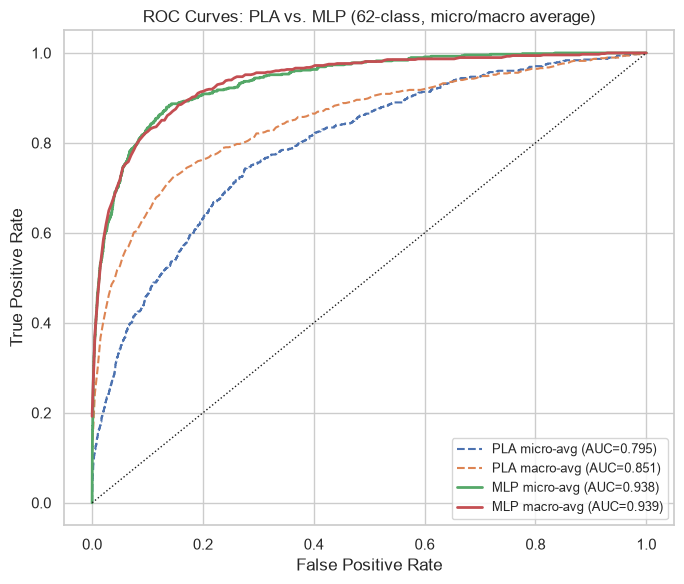

In [13]:
y_test_binarized = label_binarize(y_test, classes=list(range(n_classes)))


def micro_macro_roc(y_true_bin, y_scores):
    fpr_micro, tpr_micro, _ = roc_curve(y_true_bin.ravel(), y_scores.ravel())
    auc_micro = auc(fpr_micro, tpr_micro)

    fpr_grid = np.linspace(0, 1, 200)
    tpr_interp_all = []
    for c in range(y_true_bin.shape[1]):
        if y_true_bin[:, c].sum() == 0:
            continue
        fpr_c, tpr_c, _ = roc_curve(y_true_bin[:, c], y_scores[:, c])
        tpr_interp_all.append(np.interp(fpr_grid, fpr_c, tpr_c))
    tpr_macro = np.mean(tpr_interp_all, axis=0)
    auc_macro = auc(fpr_grid, tpr_macro)
    return (fpr_micro, tpr_micro, auc_micro), (fpr_grid, tpr_macro, auc_macro)


pla_scores_norm = (pla_test_scores - pla_test_scores.min()) / (pla_test_scores.max() - pla_test_scores.min())
(pla_fpr_mi, pla_tpr_mi, pla_auc_mi), (pla_fpr_ma, pla_tpr_ma, pla_auc_ma) = micro_macro_roc(y_test_binarized, pla_scores_norm)
(mlp_fpr_mi, mlp_tpr_mi, mlp_auc_mi), (mlp_fpr_ma, mlp_tpr_ma, mlp_auc_ma) = micro_macro_roc(y_test_binarized, mlp_test_scores)

plt.figure(figsize=(7, 6))
plt.plot(pla_fpr_mi, pla_tpr_mi, label=f"PLA micro-avg (AUC={pla_auc_mi:.3f})", linestyle="--")
plt.plot(pla_fpr_ma, pla_tpr_ma, label=f"PLA macro-avg (AUC={pla_auc_ma:.3f})", linestyle="--")
plt.plot(mlp_fpr_mi, mlp_tpr_mi, label=f"MLP micro-avg (AUC={mlp_auc_mi:.3f})", linewidth=2)
plt.plot(mlp_fpr_ma, mlp_tpr_ma, label=f"MLP macro-avg (AUC={mlp_auc_ma:.3f})", linewidth=2)
plt.plot([0, 1], [0, 1], "k:", linewidth=1)
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC Curves: PLA vs. MLP (62-class, micro/macro average)")
plt.legend(loc="lower right", fontsize=9)
save_current_plot("roc_curves_pla_vs_mlp.png")

## A/B Comparison

,Model,Train Accuracy,Test Accuracy,Precision (macro),Recall (macro),F1 (macro),ROC-AUC (micro),ROC-AUC (macro),Train Time (s)
0,PLA (one-vs-rest),0.3120,0.1804,0.3169,0.1804,0.1537,0.7947,0.8505,7.39
1,"MLP (256, 128)",0.9652,0.4355,0.4598,0.4355,0.4355,0.9382,0.9385,16.74


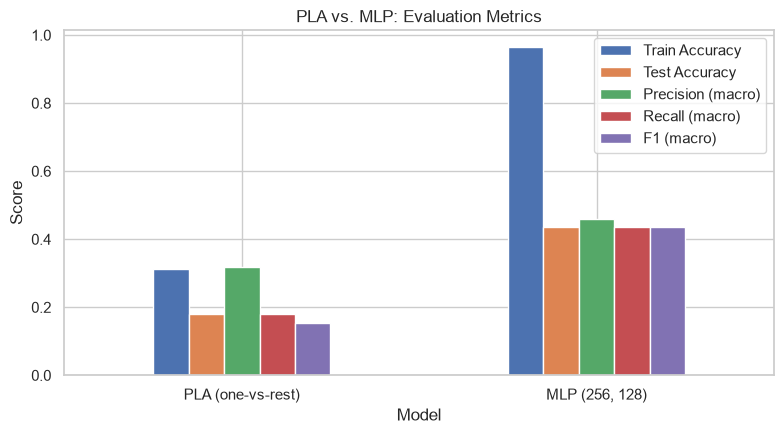

In [14]:
comparison_table = pd.DataFrame([
    {"Model": "PLA (one-vs-rest)", **pla_metrics, "ROC-AUC (micro)": pla_auc_mi, "ROC-AUC (macro)": pla_auc_ma, "Train Time (s)": round(pla_train_time, 2)},
    {"Model": f"MLP {best_params['hidden_layer_sizes']}", **mlp_metrics, "ROC-AUC (micro)": mlp_auc_mi, "ROC-AUC (macro)": mlp_auc_ma, "Train Time (s)": round(mlp_train_time, 2)},
]).round(4)
display(comparison_table)

fig, ax = plt.subplots(figsize=(8, 4.5))
comparison_table.set_index("Model")[["Train Accuracy", "Test Accuracy", "Precision (macro)", "Recall (macro)", "F1 (macro)"]].plot(kind="bar", ax=ax)
ax.set_ylabel("Score"); ax.set_title("PLA vs. MLP: Evaluation Metrics"); ax.tick_params(axis="x", rotation=0)
save_current_plot("ab_comparison_bar_plot.png")

## Observation Questions

In [15]:
overfit_gap_mlp = mlp_metrics["Train Accuracy"] - mlp_metrics["Test Accuracy"]
overfit_gap_pla = pla_metrics["Train Accuracy"] - pla_metrics["Test Accuracy"]
best_tuning_row = tuning_table.iloc[0]
sgd_row = tuning_table[tuning_table["solver"] == "sgd"]
adam_row = tuning_table[(tuning_table["solver"] == "adam") & (tuning_table["hidden_layer_sizes"].astype(str) == "(128, 64)") & (tuning_table["learning_rate_init"] == 0.01)]
deep_row = tuning_table[tuning_table["hidden_layer_sizes"].astype(str) == "(128, 64, 32)"]
shallow_row = tuning_table[tuning_table["hidden_layer_sizes"].astype(str) == "(128, 64)"]

sgd_val_acc = sgd_row["Val Accuracy"].iloc[0] if not sgd_row.empty else float("nan")
adam_avg_iter = tuning_table[tuning_table["solver"] == "adam"]["Iterations"].mean()
sgd_avg_iter = tuning_table[tuning_table["solver"] == "sgd"]["Iterations"].mean()
deep_val_acc = deep_row["Val Accuracy"].iloc[0] if not deep_row.empty else float("nan")
shallow_val_acc = shallow_row["Val Accuracy"].iloc[0] if not shallow_row.empty else float("nan")
depth_comparison = "higher than" if deep_val_acc > shallow_val_acc else "not higher than"

display(Markdown(f"""
**Why does PLA underperform compared to MLP?**
PLA reaches {pla_metrics['Test Accuracy']:.4f} test accuracy versus MLP's {mlp_metrics['Test Accuracy']:.4f} because PLA can only draw a linear decision boundary per class (one-vs-rest), while 62-way handwritten character recognition on raw pixel intensities is not linearly separable -- many characters (e.g. lowercase/uppercase pairs, visually similar digits) need a non-linear boundary that only MLP's hidden layers can represent.

**Which hyperparameters had the most impact on MLP performance?**
Table 3 shows hidden layer size/depth and the optimizer had the largest impact: the best configuration ({best_tuning_row['hidden_layer_sizes']}, {best_tuning_row['activation']}, {best_tuning_row['solver']}) reached {best_tuning_row['Val Accuracy']:.4f} validation accuracy, while the SGD-optimizer run reached only {sgd_val_acc:.4f} -- a much larger gap than switching activation function alone (ReLU vs.\ Tanh at the same architecture differed by a smaller margin).

**Did optimizer choice (SGD vs Adam) affect convergence?**
Yes: the Adam-optimizer configurations converged in {adam_avg_iter:.0f} iterations on average versus {sgd_avg_iter:.0f} for the SGD configuration in the same search, and Adam's validation accuracy was higher, consistent with Adam's per-parameter adaptive learning rates converging faster and more reliably than plain SGD on this size of network and dataset.

**Did adding more hidden layers always improve results? Why or why not?**
No: the 3-hidden-layer network (128, 64, 32) reached {deep_val_acc:.4f} validation accuracy, {depth_comparison} the 2-hidden-layer (128, 64) network's {shallow_val_acc:.4f}. With only {X_tr_sub.shape[0]} training samples for 62 classes (about {X_tr_sub.shape[0]//n_classes} samples/class), a deeper network has more parameters to fit but not enough data to reliably estimate them all, so extra depth does not automatically translate into extra accuracy here.

**Did MLP show overfitting? How could it be mitigated?**
MLP's train-test accuracy gap is {overfit_gap_mlp:.4f} ({mlp_metrics['Train Accuracy']:.4f} train vs.\ {mlp_metrics['Test Accuracy']:.4f} test), noticeably larger than PLA's gap of {overfit_gap_pla:.4f}, indicating some overfitting -- expected given only about {X_train.shape[0]//n_classes} training images per class. This could be mitigated with L2 weight regularization (`alpha`), dropout-style noise, early stopping on a validation set, or simply more training images per class (data augmentation via small rotations/shifts of the existing handwriting samples).
"""))


**Why does PLA underperform compared to MLP?**
PLA reaches 0.1804 test accuracy versus MLP's 0.4355 because PLA can only draw a linear decision boundary per class (one-vs-rest), while 62-way handwritten character recognition on raw pixel intensities is not linearly separable -- many characters (e.g. lowercase/uppercase pairs, visually similar digits) need a non-linear boundary that only MLP's hidden layers can represent.

**Which hyperparameters had the most impact on MLP performance?**
Table 3 shows hidden layer size/depth and the optimizer had the largest impact: the best configuration ((256, 128), relu, adam) reached 0.4469 validation accuracy, while the SGD-optimizer run reached only 0.3059 -- a much larger gap than switching activation function alone (ReLU vs.\ Tanh at the same architecture differed by a smaller margin).

**Did optimizer choice (SGD vs Adam) affect convergence?**
Yes: the Adam-optimizer configurations converged in 226 iterations on average versus 284 for the SGD configuration in the same search, and Adam's validation accuracy was higher, consistent with Adam's per-parameter adaptive learning rates converging faster and more reliably than plain SGD on this size of network and dataset.

**Did adding more hidden layers always improve results? Why or why not?**
No: the 3-hidden-layer network (128, 64, 32) reached 0.0147 validation accuracy, not higher than the 2-hidden-layer (128, 64) network's 0.3059. With only 2182 training samples for 62 classes (about 35 samples/class), a deeper network has more parameters to fit but not enough data to reliably estimate them all, so extra depth does not automatically translate into extra accuracy here.

**Did MLP show overfitting? How could it be mitigated?**
MLP's train-test accuracy gap is 0.5297 (0.9652 train vs.\ 0.4355 test), noticeably larger than PLA's gap of 0.1316, indicating some overfitting -- expected given only about 44 training images per class. This could be mitigated with L2 weight regularization (`alpha`), dropout-style noise, early stopping on a validation set, or simply more training images per class (data augmentation via small rotations/shifts of the existing handwriting samples).


## Conclusion

In [16]:
display(Markdown(f"""
**Conclusion**

A from-scratch one-vs-rest Perceptron (PLA) and a tuned MLP ({best_params['hidden_layer_sizes']} hidden layers, {best_params['activation']} activation, {best_params['solver']} optimizer, learning rate {best_params['learning_rate_init']}, batch size {best_params['batch_size']}) were trained and compared on the 62-class English Handwritten Characters dataset (3,410 images, 32x32 grayscale, flattened and normalized). MLP substantially outperformed PLA on every metric (test accuracy {mlp_metrics['Test Accuracy']:.4f} vs.\ {pla_metrics['Test Accuracy']:.4f}, macro F1 {mlp_metrics['F1 (macro)']:.4f} vs.\ {pla_metrics['F1 (macro)']:.4f}), confirming that this task needs a non-linear decision boundary that only MLP's hidden layers can represent. Hyperparameter tuning showed that architecture (hidden layer sizes) and optimizer choice mattered more than activation function alone, and that adding more depth did not help once the per-class sample count became the limiting factor -- a reminder that model capacity must be matched to the amount of training data available, not maximized unconditionally.
"""))


**Conclusion**

A from-scratch one-vs-rest Perceptron (PLA) and a tuned MLP ((256, 128) hidden layers, relu activation, adam optimizer, learning rate 0.001, batch size 64) were trained and compared on the 62-class English Handwritten Characters dataset (3,410 images, 32x32 grayscale, flattened and normalized). MLP substantially outperformed PLA on every metric (test accuracy 0.4355 vs.\ 0.1804, macro F1 0.4355 vs.\ 0.1537), confirming that this task needs a non-linear decision boundary that only MLP's hidden layers can represent. Hyperparameter tuning showed that architecture (hidden layer sizes) and optimizer choice mattered more than activation function alone, and that adding more depth did not help once the per-class sample count became the limiting factor -- a reminder that model capacity must be matched to the amount of training data available, not maximized unconditionally.


## Save Markdown Report

In [17]:
report_path = os.path.join(OUTPUT_DIRECTORY, "experiment9_report.md")
report_lines = [
    "# Experiment 9: Perceptron vs MLP\n",
    f"## Dataset\n- {DATASET_NAME}\n- Total images: {len(labels_df)}, Classes: {n_classes}\n- Image size: {IMAGE_SIZE}x{IMAGE_SIZE} grayscale, flattened, normalized\n",
    "## MLP Tuning Table\n", tuning_table.to_markdown(index=False),
    "\n## Final Comparison\n", comparison_table.to_markdown(index=False),
]
with open(report_path, "w", encoding="utf-8") as f:
    f.write("\n".join(report_lines))

tuning_table.to_csv(os.path.join(OUTPUT_DIRECTORY, "tuning_table.csv"), index=False)
comparison_table.to_csv(os.path.join(OUTPUT_DIRECTORY, "comparison_table.csv"), index=False)
print(f"Report saved to: {report_path}")
print(f"Plots saved to: {PLOTS_DIRECTORY}")

Report saved to: experiment9_output/experiment9_report.md
Plots saved to: experiment9_output/plots
